In [1]:
# Importamos la librería pandas (la herramienta para manejar tablas de datos)
import pandas as pd

# Leemos el archivo CSV. Este dataset usa ";" como separador, no comas
df = pd.read_csv("student-por.csv", sep=";")

# Mostramos las primeras 5 filas para confirmar que cargó bien
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [2]:
# Mostrar cuántas filas y columnas tiene el dataset que subimos
print("Forma (filas, columnas):", df.shape)

# Mostrar los tipos de cada variable (número o texto)
print("\nTipos de datos:")
print(df.dtypes)


Forma (filas, columnas): (649, 33)

Tipos de datos:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [3]:
#Mostrar el resumen de las variables numéricas
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [4]:
# Mostrar cuántos valores nulos (vacíos) hay por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Mostrar cuántas filas duplicadas hay
print("\nFilas duplicadas:", df.duplicated().sum())


Valores nulos por columna:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Filas duplicadas: 0


In [5]:
# Mostrar cómo se distribuyen las notas finales (G3)
print("Distribución de la nota final G3:")
print(df["G3"].describe())

# Mostrar conteo (Contamos cuántos estudiantes hay en cada nota)
print("\nConteo por nota final:")
print(df["G3"].value_counts().sort_index())


Distribución de la nota final G3:
count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64

Conteo por nota final:
G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


In [6]:
# Ahora creamos la variable objetivo "riesgo":
# Si la nota final G3 es menor a 10, el estudiante está EN RIESGO (1)
# Si la nota final es 10 o más, NO está en riesgo (0)
df["riesgo"] = (df["G3"] < 10).astype(int)

# Ahora vemos cuántos estudiantes hay en cada grupo
print("Conteo de la variable riesgo:")
print(df["riesgo"].value_counts())

# Ahora vemos el porcentaje
print("\nPorcentaje de cada clase:")
print(df["riesgo"].value_counts(normalize=True) * 100)

Conteo de la variable riesgo:
riesgo
0    549
1    100
Name: count, dtype: int64

Porcentaje de cada clase:
riesgo
0    84.59168
1    15.40832
Name: proportion, dtype: float64


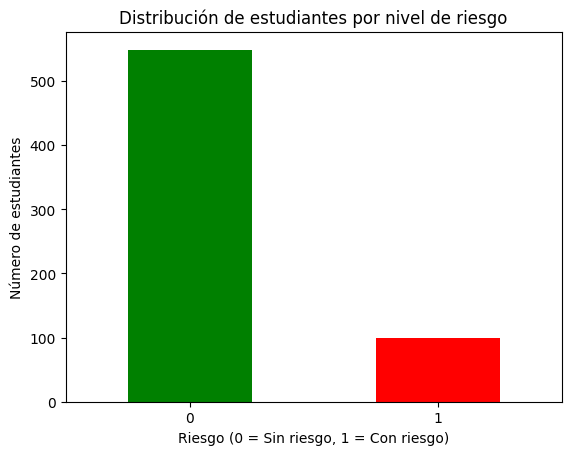

In [7]:
#importamos matplotlib (librería de gráficos y se le pone el apodo plt)
import matplotlib.pyplot as plt

# Gráfico de barras de la variable riesgo
#.plot(kind="bar", ...) - dibuja barras; le decimos que la de "sin riesgo" sea verde y la de "con riesgo" roja
#plt.title, plt.xlabel, plt.ylabel - ponen el título y las etiquetas de los ejes
df["riesgo"].value_counts().plot(kind="bar", color=["green", "red"])
plt.title("Distribución de estudiantes por nivel de riesgo")
plt.xlabel("Riesgo (0 = Sin riesgo, 1 = Con riesgo)")
plt.ylabel("Número de estudiantes")
#plt.xticks(rotation=0) - mantiene los números del eje derechos (sin inclinar)
plt.xticks(rotation=0)
#plt.show() - muestra el gráfico
plt.show()


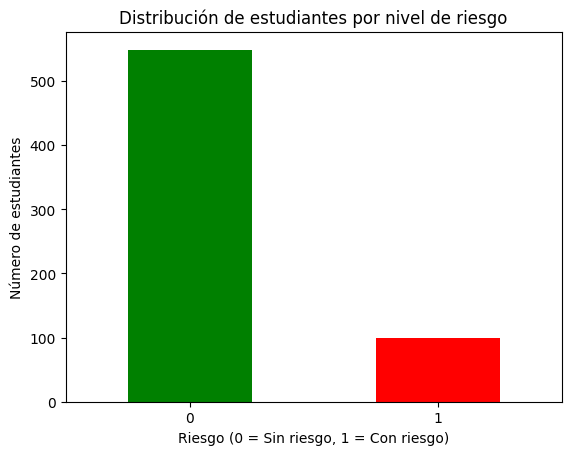

Gráfico guardado como distribucion_riesgo.png


In [8]:
# Volvemos a crear el gráfico y lo guardamos como imagen
df["riesgo"].value_counts().plot(kind="bar", color=["green", "red"])
plt.title("Distribución de estudiantes por nivel de riesgo")
plt.xlabel("Riesgo (0 = Sin riesgo, 1 = Con riesgo)")
plt.ylabel("Número de estudiantes")
plt.xticks(rotation=0)

# Guardamos la imagen en Colab
plt.savefig("distribucion_riesgo.png", bbox_inches="tight")
plt.show()

print("Gráfico guardado como distribucion_riesgo.png")


In [9]:
# Correlación entre las tres notas (G1, G2, G3)
print(df[["G1", "G2", "G3"]].corr())


          G1        G2        G3
G1  1.000000  0.864982  0.826387
G2  0.864982  1.000000  0.918548
G3  0.826387  0.918548  1.000000
